
# 1. Introduction

In this project, we investigate technical price indicators derived from open, high, low, close and volume data obtained on a representative subset of large cap US stocks (such as AAPL, MSFT, AMZN, GOOGL, NVDA, and META) contain enough information to predict whether large-cap U.S. stocks will provide a positive return in the next five trading days. 

Utilizing ML for directional prediction could support a data-driven decision-making when compared to naive guessing or intuition-based trading.

We plan to use momentum, moving average, and volatility indicators for the predictions. However, we note that real world details and noise will likely mean that the models cannot be perfect. 


## 2. Research Question

Can technical price indicators predict whether large-cap U.S. stocks will generate a positive return in the next five trading days?

## 3. Data Sources

Selected Data Source: Yahoo Finance via `yfinance`  
Modeling Plan: Logistic Regression based on technical indicators to classify market direction


In [1]:

# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Optional notebook settings
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42



## 4. Data Collection

This project uses daily historical stock data from Yahoo Finance through the `yfinance` package. A representative subset of large-cap U.S. equities is used rather than attempting to reconstruct historical S&P 500 membership over time.

**Example tickers:** AAPL, MSFT, AMZN, GOOGL, NVDA, META


In [2]:

# Representative subset of large-cap U.S. stocks previously downloaded using yfinance from 1/1/2015 to 4/22/2026 (consistent data range across all tickers)
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "NVDA", "META"] 

# Data loading
raw = pd.read_csv("data/stock_data.csv", header=[0, 1], index_col=0) # Read the CSV with multi-level columns (ticker and attribute)
raw.head()



Ticker           META                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2015-01-02  78.580002  78.930000  77.699997  78.449997  77.839149  18177500   
2015-01-05  77.980003  79.250000  76.860001  77.190002  76.588966  26452200   
2015-01-06  77.230003  77.589996  75.360001  76.150002  75.557060  27399300   
2015-01-07  76.760002  77.360001  75.820000  76.150002  75.557060  22045300   
2015-01-08  76.739998  78.230003  76.080002  78.180000  77.571259  23961000   

Ticker         AMZN                                                     GOOGL  \
Price          Open     High      Low    Close Adj Close    Volume       Open   
Date                                                                            
2015-01-02  15.6290  15.7375  15.3480  15.4260   15.4260  55664000  26.629999   
2015-01-05  15.3505  15.4190  15.0425  15.1095   15.1095  55484000  26.357500   
2015-01-06  15.1120  15.1500  14.6190  14.7645   14.7645  70380000  26.025000   
2015-01-07  14.8750  15.0640  14.7665  14.9210   14.9210  52806000  25.547501   
2015-01-08  15.0160  15.1570  14.8055  15.0230   15.0230  61768000  25.075500   

Ticker                                                                 MSFT  \
Price            High        Low      Close  Adj Close    Volume       Open   
Date                                                                          
2015-01-02  26.790001  26.393999  26.477501  26.260462  26480000  46.660000   
2015-01-05  26.399500  25.887501  25.973000  25.760094  41182000  46.369999   
2015-01-06  26.060499  25.277500  25.332001  25.124350  54456000  46.380001   
2015-01-07  25.574499  25.182501  25.257500  25.050457  46918000  45.980000   
2015-01-08  25.375000  24.750999  25.345501  25.137737  73054000  46.750000   

Ticker                                                               NVDA  \
Price            High        Low      Close  Adj Close    Volume     Open   
Date                                                                        
2015-01-02  47.419998  46.540001  46.759998  39.767700  27913900  0.50325   
2015-01-05  46.730000  46.250000  46.330002  39.401985  39673900  0.50325   
2015-01-06  46.750000  45.540001  45.650002  38.823685  36447900  0.49550   
2015-01-07  46.459999  45.490002  46.230000  39.316940  29114100  0.48325   
2015-01-08  47.750000  46.720001  47.590000  40.473576  29645200  0.48400   

Ticker                                                           AAPL  \
Price          High      Low    Close Adj Close     Volume       Open   
Date                                                                    
2015-01-02  0.50700  0.49525  0.50325  0.482985  113680000  27.847500   
2015-01-05  0.50475  0.49250  0.49475  0.474828  197952000  27.072500   
2015-01-06  0.49600  0.47925  0.47975  0.460432  197764000  26.635000   
2015-01-07  0.48750  0.47700  0.47850  0.459232  321808000  26.799999   
2015-01-08  0.49950  0.48375  0.49650  0.476507  283780000  27.307501   

Ticker                                                             
Price            High        Low      Close  Adj Close     Volume  
Date                                                               
2015-01-02  27.860001  26.837500  27.332500  24.214897  212818400  
2015-01-05  27.162500  26.352501  26.562500  23.532713  257142000  
2015-01-06  26.857500  26.157499  26.565001  23.534939  263188400  
2015-01-07  27.049999  26.674999  26.937500  23.864948  160423600  
2015-01-08  28.037500  27.174999  27.972500  24.781891  237458000


## 5. Data Cleaning

The data has multiple indices, we add ticker as a column, and reformat with one row for each date for each ticker. 

In [3]:
# Reshape the multi-index DataFrame into a long format with a single index
def reshape_yfinance_download(raw_data, ticker_list):
    frames = [] # list to hold individual ticker DataFrames

    for ticker in ticker_list:
        df_ticker = raw_data[ticker].copy()
        df_ticker["ticker"] = ticker
        df_ticker = df_ticker.reset_index()
        frames.append(df_ticker)

    df = pd.concat(frames, ignore_index=True) # concatenate all ticker DataFrames into one
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df



df = reshape_yfinance_download(raw, tickers)
df.head()

,date,open,high,low,close,adj_close,volume,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.214897,212818400,AAPL
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,23.532713,257142000,AAPL
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,23.534939,263188400,AAPL
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,23.864948,160423600,AAPL
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,24.781891,237458000,AAPL



Check dataset shape, date range, missing values, duplicates, and basic summary statistics.


In [4]:

print("Shape:", df.shape)
print("\nDate range:", df["date"].min(), "to", df["date"].max())
print("\nTickers:", df["ticker"].nunique())
print("\nMissing values:")
print(sum(df.isna().sum()))
print("\nValue Counts:")
print(df["ticker"].value_counts().mean())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (17046, 8)

Date range: 2015-01-02 00:00:00 to 2026-04-21 00:00:00

Tickers: 6

Missing values:
0

Value Counts:
2841.0

Duplicate rows: 0


In [5]:
df.info() # check data types and non-null counts for each column to identify potential issues with missing values or incorrect data types that may need to be addressed during preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17046 entries, 0 to 17045
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       17046 non-null  datetime64[ns]
 1   open       17046 non-null  float64       
 2   high       17046 non-null  float64       
 3   low        17046 non-null  float64       
 4   close      17046 non-null  float64       
 5   adj_close  17046 non-null  float64       
 6   volume     17046 non-null  int64         
 7   ticker     17046 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.0+ MB


In [6]:
df.describe(include="all") # provides summary statistics for numeric and categorical columns

,date,open,high,low,close,adj_close,volume,ticker
count,17046,17046.000000,17046.000000,17046.000000,17046.000000,17046.000000,1.704600e+04,17046
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAPL
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2841
mean,2020-08-24 02:00:07.602956544,142.465963,144.080402,140.807720,142.493563,140.582364,1.177051e+08,NaN
min,2015-01-02 00:00:00,0.481250,0.487500,0.473500,0.478500,0.459232,4.726100e+06,NaN
25%,2017-10-26 00:00:00,43.750001,44.065250,43.387751,43.817751,41.527056,2.511772e+07,NaN
50%,2020-08-24 00:00:00,113.080002,114.739998,111.599998,113.246502,111.570763,4.517740e+07,NaN
75%,2023-06-21 00:00:00,186.424999,188.387501,184.217503,186.424995,185.442245,1.114906e+08,NaN
max,2026-04-21 00:00:00,791.150024,796.250000,780.820007,790.000000,788.148987,3.692928e+09,NaN



## 6. Feature Engineering

As we plan to answer the research questions, several financial indicators are calculated based on the chronological timeframe - using only information available up to time "t".

Baseline features:
#### Momentum and recent return indicators
- daily returns
- 5-day and 10-day momentum (Return over the past five and ten trading days.)
#### Trend and moving average
- 5-day and 20-day moving averages (short-term to long-term moving averages.)
- moving average ratio (Ratio of short-term to long-term moving averages. Momentum strength or downward trend)
#### Volatility
- rolling volatility (standard deviation over duration - stability)
- RSI (14) (Overbought or oversold)
- volume change % (from prior day)
- high-low range % (ratio of high to low)
- open close change % (% of open price)


In [7]:

# Function definitions to compute technical indicators
def compute_rsi(series, window=14): # computes the Relative Strength Index (RSI) for a given price series and window size
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_technical_features(data): # computes various technical indicators and features for each stock ticker group
    data = data.copy()
    data = data.sort_values(["ticker", "date"])

    grouped = data.groupby("ticker", group_keys=False) # group by ticker to compute features separately for each stock, group_keys=False ensures the original index is preserved
    data["ret_1d"] = grouped["close"].pct_change(1) # percentage change in close price from previous day
    data["ret_5d"] = grouped["close"].pct_change(5)
    data["ret_10d"] = grouped["close"].pct_change(10)

    data["ma_5"] = grouped["close"].transform(lambda s: s.rolling(5).mean()) # computes 5-day moving average of close price for each ticker group
    data["ma_10"] = grouped["close"].transform(lambda s: s.rolling(10).mean())
    data["ma_20"] = grouped["close"].transform(lambda s: s.rolling(20).mean())

    data["ma_ratio_5_20"] = data["ma_5"] / data["ma_20"]
    data["price_vs_ma20"] = data["close"] / data["ma_20"]

    data["volatility_10"] = grouped["ret_1d"].transform(lambda s: s.rolling(10).std())
    data["volatility_20"] = grouped["ret_1d"].transform(lambda s: s.rolling(20).std())

    data["rsi_14"] = grouped["close"].transform(lambda s: compute_rsi(s, window=14)) # computes RSI for each ticker group

    data["volume_change_1d"] = grouped["volume"].pct_change(1) # percentage change in volume from previous day
    data["volume_ma_10"] = grouped["volume"].transform(lambda s: s.rolling(10).mean())
    data["volume_ratio"] = data["volume"] / data["volume_ma_10"]

    data["hl_range"] = (data["high"] - data["low"]) / data["close"] # high-low range as a percentage of close price
    data["oc_change"] = (data["close"] - data["open"]) / data["open"] # open-close change as a percentage of open price

    return data

df_feat = add_technical_features(df) # adds technical features to the original DataFrame
df_feat.head(5)


,date,open,high,low,close,adj_close,volume,ticker,ret_1d,ret_5d,ret_10d,ma_5,ma_10,ma_20,ma_ratio_5_20,price_vs_ma20,volatility_10,volatility_20,rsi_14,volume_change_1d,volume_ma_10,volume_ratio,hl_range,oc_change
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.214897,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037410,-0.018494
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,23.532713,257142000,AAPL,-0.028172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.208270,NaN,NaN,0.030494,-0.018838
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,23.534939,263188400,AAPL,0.000094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023514,NaN,NaN,0.026350,-0.002628
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,23.864948,160423600,AAPL,0.014022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.390461,NaN,NaN,0.013921,0.005131
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,24.781891,237458000,AAPL,0.038422,NaN,NaN,27.074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.480194,NaN,NaN,0.030834,0.024352



#### Defining the target variable

- `1` if the stock's return over the next 5 trading days is positive
- `0` otherwise

Hence, this is a binary supervised learning learning application.


In [8]:

df_feat["future_return_5d"] = (
    df_feat.groupby("ticker")["close"].shift(-5) / df_feat["close"] - 1
) # computes the 5-day future return for each ticker group by pulling the close price 5 days into the future into calculation with the current row and calculating the percentage change from the current close price

df_feat["target"] = (df_feat["future_return_5d"] > 0).astype(int) # creates a binary target variable where 1 indicates the stock price will go up in the next 5 days and 0 indicates it will go down or stay the same

df_feat[["ticker", "date", "close", "future_return_5d", "target"]].head(5)


,ticker,date,close,future_return_5d,target
0,AAPL,2015-01-02,27.332500,0.024513,1
1,AAPL,2015-01-05,26.562500,0.028235,1
2,AAPL,2015-01-06,26.565001,0.037267,1
3,AAPL,2015-01-07,26.937500,0.019026,1
4,AAPL,2015-01-08,27.972500,-0.045312,0



## 7. Exploratory Data Analysis

To explore the data, we take a look at charts and trends of several features over time and relevant distributions:

- price history over time
- volume behavior
- return distribution
- class balance after target creation
- correlation heatmap of engineered numeric features

No extreme outliers were removed, as financial return distributions will contain large movements as part of the natural response to certain downturns or rallies.


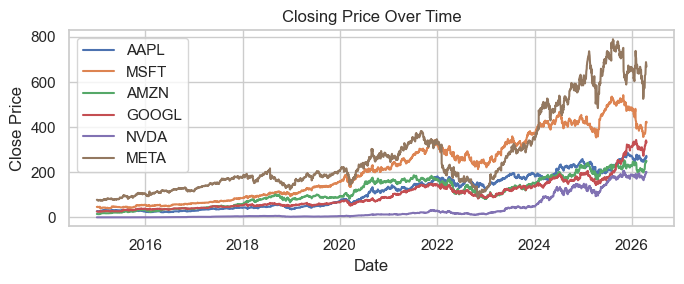

In [9]:
# Closing price over time
plt.figure(figsize=(7, 3))
for ticker in tickers:
    subset = df[df["ticker"] == ticker]
    plt.plot(subset["date"], subset["close"], label=ticker)

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


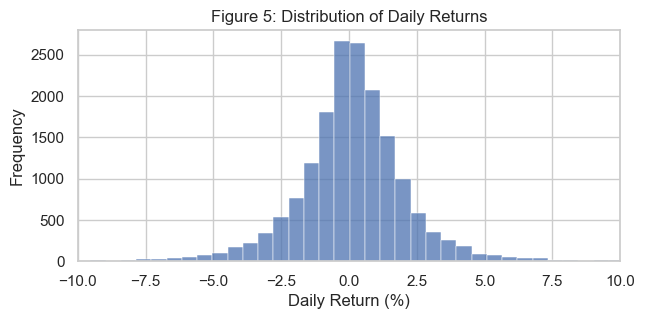

In [10]:
# Return Distribution
plt.figure(figsize=(7, 3))
sns.histplot(df_feat["ret_1d"] * 100, bins=100)
plt.title("Figure 5: Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.xlim(-10, 10)
plt.show()

For 1 day returns we see the concentation around 0 with occasional extremes.

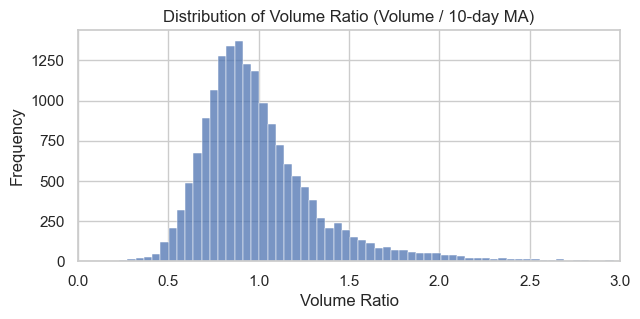

In [11]:
# Volume Distribution
plt.figure(figsize=(7, 3))
sns.histplot(df_feat["volume_ratio"], bins=100)
plt.title("Distribution of Volume Ratio (Volume / 10-day MA)")
plt.xlabel("Volume Ratio")
plt.ylabel("Frequency")
plt.xlim(0, 3)
plt.show()


The chart above is the ratio of the volume and the 10 day moving average. Most days we see average volume.

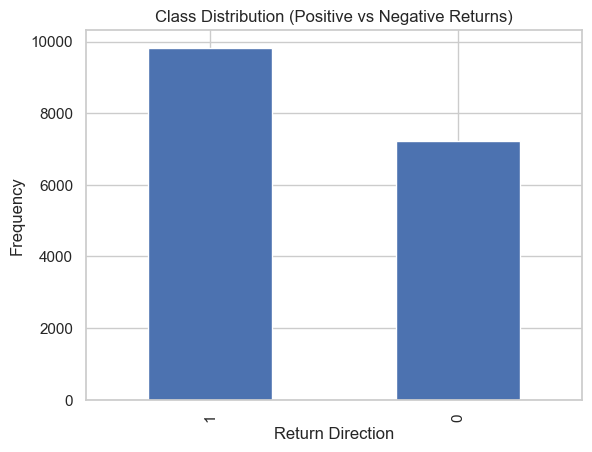

In [12]:
df_feat["target"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Positive vs Negative Returns)")
plt.xlabel("Return Direction")
plt.ylabel("Frequency")
plt.show()


In [13]:
# We see that the classes are relatively balanced, which is good for modeling. 
df_feat["target"].value_counts(normalize=True)

target
1    0.57644
0    0.42356
Name: proportion, dtype: float64

The data seems to have a slight imbalance with slightly higher % of 5-day positive return trends.

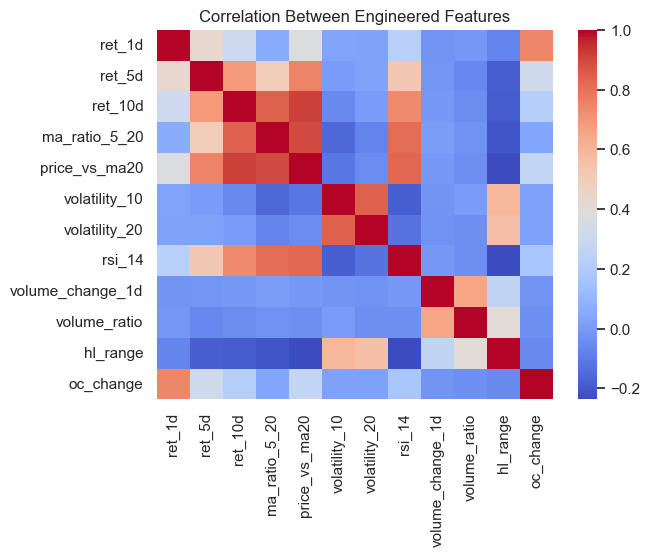

In [14]:
# Consider technical indicators and engineered features for correlation analysis
feature_cols = [
    "ret_1d", "ret_5d", "ret_10d",
    "ma_ratio_5_20", "price_vs_ma20",
    "volatility_10", "volatility_20",
    "rsi_14",
    "volume_change_1d", "volume_ratio",
    "hl_range", "oc_change"
]
sns.heatmap(df_feat[feature_cols].corr(), cmap="coolwarm")
plt.title("Correlation Between Engineered Features")
plt.show()

We see that some indicators such as moving average are correlated because they are derived from similar price information.


## 8. Modeling Approach

Select modeling columns - price indicators, ticker, date and target. We remove rows with NA where rolling averages are outside the window for inputs and preserve chronological order.

Data leakage prevention:

Since we have a time series like data that is chronological, all features will be constructed using historical data available at a time "t" and we split chronologically to avoid look-ahead bias. 



In [15]:
model_df = df_feat[["date", "ticker", "target"] + feature_cols].copy()
model_df = model_df.dropna().sort_values(["date", "ticker"]).reset_index(drop=True)

print(model_df.shape)
model_df.head(5)


(16926, 15)


,date,ticker,target,ret_1d,ret_5d,ret_10d,ma_ratio_5_20,price_vs_ma20,volatility_10,volatility_20,rsi_14,volume_change_1d,volume_ratio,hl_range,oc_change
0,2015-02-02,AAPL,1,0.012547,0.048895,0.119257,1.042495,1.067714,0.025471,0.023813,66.039668,-0.250836,0.862608,0.026047,0.004913
1,2015-02-02,AMZN,1,0.028037,0.177001,0.253594,1.074434,1.192852,0.044254,0.035554,83.761550,-0.571099,1.366119,0.041128,0.041194
2,2015-02-02,GOOGL,0,-0.009953,-0.008422,0.042589,1.014084,1.031291,0.023371,0.018695,66.007656,-0.377597,1.307302,0.027772,-0.003968
3,2015-02-02,META,0,-0.012120,-0.032387,-0.002527,0.995238,0.979640,0.016100,0.015729,43.699916,-0.016277,1.299892,0.031871,-0.014716
4,2015-02-02,MSFT,1,0.021782,-0.121889,-0.107266,0.917507,0.912467,0.036167,0.027406,29.632463,-0.354496,0.805006,0.027616,0.016999


In [16]:
# We see that the classes are relatively balanced, which is good for modeling. We can proceed with training a classification model to predict the target variable based on the engineered features.
model_df["target"].value_counts(normalize=True)

target
1    0.57651
0    0.42349
Name: proportion, dtype: float64


#### Train / Validation / Test Split

- Train: earliest 70%
- Validation: next 15%
- Test: final 15%


In [17]:

unique_dates = np.sort(model_df["date"].unique()) # get unique dates and sort them to ensure chronological order for time-based splitting

train_end = int(len(unique_dates) * 0.70) # test set will be the last 15% of dates, validation set will be the 15% before that, and training set will be the first 70%
valid_end = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_end]
valid_dates = unique_dates[train_end:valid_end]
test_dates = unique_dates[valid_end:]

train_df = model_df[model_df["date"].isin(train_dates)].copy()
valid_df = model_df[model_df["date"].isin(valid_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_valid = valid_df[feature_cols]
y_valid = valid_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)


Train: (11844, 15)
Valid: (2538, 15)
Test : (2544, 15)



## 9. Baseline Logistic Regression

Logistic regression is a good baseline model since the target is binary, the coefficients are interpretable, the modeling approach is efficient and lastly, it helps build a foundational benchmark before trying more complex models


In [18]:

numeric_features = feature_cols # technical indicators and engineered features are all numeric

baseline_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)) # logistic regression is a simple and interpretable baseline model for binary classification
])

baseline_pipe.fit(X_train, y_train)

valid_pred = baseline_pipe.predict(X_valid)
valid_prob = baseline_pipe.predict_proba(X_valid)[:, 1]

print("Validation Accuracy :", accuracy_score(y_valid, valid_pred))
print("Validation Precision:", precision_score(y_valid, valid_pred))
print("Validation Recall   :", recall_score(y_valid, valid_pred))
print("Validation F1       :", f1_score(y_valid, valid_pred))
print("Validation ROC-AUC  :", roc_auc_score(y_valid, valid_prob))


Validation Accuracy : 0.607565011820331
Validation Precision: 0.6101356743814844
Validation Recall   : 0.9877260981912145
Validation F1       : 0.7543167242229897
Validation ROC-AUC  : 0.46875864589042887


We see that the ROC-AUC score for the baseline model is ~0.47


#### Hyperparameter Tuning

Use time-aware cross-validation for tuning `C`, penalty strength, and class weighting.


In [19]:

tscv = TimeSeriesSplit(n_splits=5) # time series cross-validation to ensure chronological order of training and validation sets during hyperparameter tuning

param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0], # regularization strength - smaller values high bias, larger values low bias but higher variance
    "logreg__class_weight": [None, "balanced"] # class parameter to check balanced vs unbalanced class weighting
}

grid = GridSearchCV(
    estimator=baseline_pipe,
    param_grid=param_grid,
    scoring="roc_auc", # using ROC-AUC as the primary metric for hyperparameter - binary classification
    cv=tscv,
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)
best_model = grid.best_estimator_



Best params: {'logreg__C': 0.01, 'logreg__class_weight': 'balanced'}
Best CV ROC-AUC: 0.5128338670438481



## 10. Model Evaluation


We're selecting ROC-AUC as the main evaluation criteria because it measures the model’s ability to distinguish between classes across all classification thresholds, making it more appropriate than accuracy for this problem.

Regularization strength of 0.01 indicates a relatively high bias model, and balanced class weight helps address any class imbalance by weighting classes inversely proportional to their frequency in the training data. The best hyperparameters only slightly improved the ROC-AUC compared to the default logistic regression model, which suggests that this simple linear model may not be capturing complex patterns in the data, and more advanced models or additional features may be needed to achieve better predictive performance.

In [20]:

test_pred = best_model.predict(X_test) # predictions on the hold-out test set to evaluate final model performance on unseen data
test_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob),
}

metrics


{'accuracy': 0.5180817610062893,
 'precision': 0.5643712574850299,
 'recall': 0.5393419170243204,
 'f1': 0.5515727871250914,
 'roc_auc': 0.5130409435568638}

In [21]:

print(classification_report(y_test, test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.47      0.49      0.48      1146
           1       0.56      0.54      0.55      1398

    accuracy                           0.52      2544
   macro avg       0.52      0.52      0.52      2544
weighted avg       0.52      0.52      0.52      2544

Confusion matrix:
 [[564 582]
 [644 754]]


On the hold out test set, the model achieves an accuracy of around 52%, with a precision of 47% for the negative class (0) and 56% for the positive class (1). The recall is 49% for class 0 and 54% for class 1, resulting in an F1-score of approximately 0.48 for class 0 and 0.55 for class 1. The model's performance on the test set is around 51.3% ROC-AUC, which indicates that the model has very limited ability to discriminate between the two classes (positive vs negative returns). This suggests that the model is not effectively capturing the underlying patterns in the data to make accurate predictions about future stock price movements. 

The confusion matrix shows that the model is correctly predicting 564 true negatives and 754 true positives, but also has a significant number of false positives (582) and false negatives (644), indicating there is room for improvement in the model's predictive performance. 

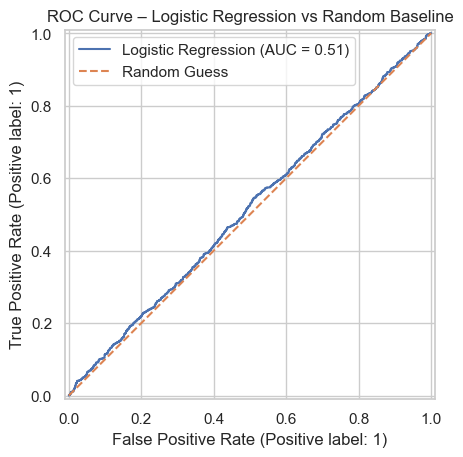

In [22]:

RocCurveDisplay.from_predictions(y_test, test_prob, name="Logistic Regression")
plt.title("ROC Curve - Logistic Regression Baseline")
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.title("ROC Curve – Logistic Regression vs Random Baseline")
plt.legend()
plt.show()


The ROC curve closely follows the diagonal, confirming that the model performs near random guessing.

The ROC curve lies close to the diagonal reference line, indicating that the model has little ability to distinguish between positive and negative five-day returns. The ROC-AUC of approximately 0.51 suggests that the model performs only marginally better than random guessing, confirming that the technical indicators used provide limited predictive signal.

Adding a majority class baseline:

In [23]:
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean()) # majority class baseline accuracy - the accuracy you would get by always predicting the most frequent class in the test set, serves as a simple benchmark to compare model performance against
print("Majority class baseline accuracy:", baseline_accuracy)

Majority class baseline accuracy: 0.5495283018867925


Adding a random baseline:

In [24]:
np.random.seed(RANDOM_STATE)
random_preds = np.random.rand(len(y_test))
fpr_random, tpr_random, _ = roc_curve(y_test, random_preds)
roc_auc_random = roc_auc_score(y_test, random_preds)
# Random accuracy
random_accuracy = accuracy_score(y_test, (random_preds > 0.5).astype(int)) # converting random probabilities to binary predictions using a threshold of 0.5 for accuracy calculation
print("Random predictions ROC-AUC:", roc_auc_random)
print("Random predictions Accuracy:", random_accuracy)


Random predictions ROC-AUC: 0.5062124401101549
Random predictions Accuracy: 0.5078616352201258


The majority-class baseline achieved approximately 55% accuracy by always predicting the more frequent class. The logistic regression model achieved lower accuracy at approximately 52%, although ROC-AUC is the more important metric here because it evaluates ranking/separation across thresholds. The random prediction baseline produced ROC-AUC of approximately 0.51, similar to the logistic regression model, indicating that the model has limited predictive power.

Overall, the model performs only slightly better than random guessing and worse than the majority-class baseline in accuracy.


## 11. Feature Interpretation

Because Logistic Regression is interpretable, utilizing visuals to inspect the sign and magnitude of coefficients after scaling.


In [25]:

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": best_model.named_steps["logreg"].coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df


,feature,coefficient
3,ma_ratio_5_20,0.096340
4,price_vs_ma20,0.058735
0,ret_1d,0.040539
9,volume_ratio,0.008995
5,volatility_10,0.007877
6,volatility_20,-0.007638
8,volume_change_1d,-0.013838
10,hl_range,-0.024092
7,rsi_14,-0.036165
1,ret_5d,-0.056390


Text(0.5, 1.0, 'Logistic Regression Feature Coefficients')

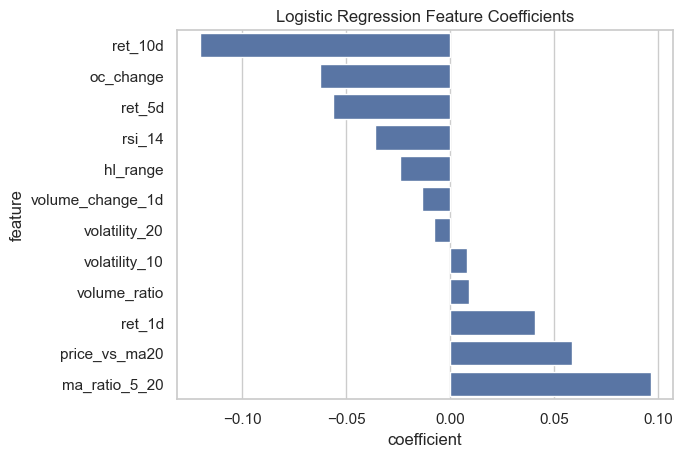

In [26]:

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": best_model.named_steps["logreg"].coef_[0]
}).sort_values("coefficient")
sns.barplot(data=coef_df, x="coefficient", y="feature")
plt.title("Logistic Regression Feature Coefficients")



## 12. Findings Summary

The logistic regression coefficients suggest the presence of weak and competing effects between momentum and mean reversion. Indicators such as the moving average ratio (MA5/MA20), price relative to the 20-day moving average, and one-day returns exhibit small positive coefficients, indicating a slight tendency toward short-term momentum.

In contrast, longer-term return measures (5-day and 10-day returns), RSI, and intraday price changes show negative coefficients, suggesting mild mean reversion effects, where recent gains may be followed by short-term pullbacks.

However, the magnitude of these coefficients is small, and the model’s overall performance (ROC-AUC ≈ 0.50) indicates that these relationships are weak and do not translate into meaningful predictive power. This suggests that while certain technical patterns may exist, they are not sufficiently strong or stable to reliably predict short-term stock returns in large-cap equities.

This combination of weak momentum and mean reversion effects is consistent with the intuition that short-term stock price movements are often noisy and difficult to predict using technical indicators alone.


## 13. Limitations

The limitations of the model include the lack of several dynamic factors which are not accounted for. Only technical indicators are used but macro or market information is not included. Changes in market behavior over time, dependence between stocks such as correlations among selected stocks are not included in the model. The model doesn't account for transaction costs for buying and selling of the stock. The prediction horizon is also only 5 days. 

Further, the weak signal may reflect the high efficiency of large-cap equity markets, where publicly available technical indicators are quickly incorporated into prices.


## 14. Next Steps

Adding SPY market features, VIX volatility index and including industry/ sector information would help add some external aspects to only technical indicators. Also comparing with tree-based models, testing other prediction timeframes will provide more understanding and help evaluate the performance of the strategy.


## 15. Conclusion

This notebook presents a baseline model for investigating whether technical indicators can predict short-term positive returns in large-cap U.S. stocks. In this exploration we have developed a foundation: data acquisition, established parameters, feature engineering, chronological train/ test splitting, baseline comparisons and evaluation.